# CIND820 Milestone 3 — Notebook 04: Model Training & Cross-Validation
**Student:** Mubarak Ahmed (501345730)
**Pipeline Stage:** Stage 5 (Model Training & Cross-Validation)

**Purpose:** Train and compare three classifiers under two class-imbalance strategies using
stratified 5-fold cross-validation on the **training split only**. The held-out test set is not
touched in this notebook — it is reserved for final evaluation in Notebook 05.

| Component | Choice | Rationale |
|---|---|---|
| Baseline | Logistic Regression (C=1, scaled, balanced weights) | Interpretable linear benchmark — the "current implicit model" |
| Alternate | Random Forest (100 trees) | Non-linear reference point between baseline and champion |
| Champion candidate | XGBoost (500 trees, early stopping, depth 6) | Best prior evidence on tabular logistics data |
| Imbalance strategy A | Balanced class weights (sample weights for XGBoost) | Reweights real data, no synthetic samples |
| Imbalance strategy B | SMOTE (k=5), applied **inside each training fold only** | Standard oversampling comparison |
| Metrics | Macro-averaged F1 (primary), macro AUPRC, fit/predict time | Imbalance-robust; accuracy is uninformative at 88.5% majority share |

**Leakage controls in this notebook:** SMOTE is applied only to the training portion of each
fold (never the validation fold); XGBoost's early-stopping eval set is carved from the fold's
training portion and kept un-resampled; logistic regression's StandardScaler is fitted within
each fold. All of this is implemented in `src/models.py`.

In [1]:
# Section 1: Imports and data
import sys
sys.path.append('../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import models

train = pd.read_parquet('../data/processed/X_train.parquet')
X = train.drop(columns=['delay_class'])
y = train['delay_class']
print(f"Training matrix: {X.shape} | class counts: {y.value_counts().sort_index().tolist()}")

Training matrix: (8259, 154) | class counts: [7310, 553, 396]


## Section 2: Run the cross-validation grid

3 models × 2 imbalance strategies × 5 stratified folds = 30 model fits.
Expected runtime: roughly 1–3 minutes on a standard laptop.

In [2]:
# Full CV grid — one row per model-strategy-fold
cv_results = models.run_cross_validation(X, y)
cv_results.to_csv('../outputs/tables/cv_results_per_fold.csv', index=False)
print(f"{len(cv_results)} fold-level results saved to outputs/tables/cv_results_per_fold.csv")
cv_results.head(6)

30 fold-level results saved to outputs/tables/cv_results_per_fold.csv


,model,strategy,fold,macro_f1,auprc_macro,fit_time_s,pred_time_s,n_train_after_resample
0,LogisticRegression,class_weight,1,0.359746,0.422331,0.369,0.0049,5946
1,RandomForest,class_weight,1,0.466963,0.506433,0.678,0.0316,5946
2,XGBoost,class_weight,1,0.576757,0.566759,2.902,0.0476,5946
3,LogisticRegression,smote,1,0.410059,0.423490,1.478,0.0050,15789
4,RandomForest,smote,1,0.475177,0.490915,2.223,0.0348,15789
5,XGBoost,smote,1,0.467827,0.501415,6.658,0.0264,15789


In [3]:
# Summary: mean ± std per configuration, ranked by macro-F1
cv_summary = models.summarize_cv(cv_results)
cv_summary.to_csv('../outputs/tables/cv_summary.csv', index=False)
cv_summary

,model,strategy,macro_f1_mean,macro_f1_std,auprc_mean,auprc_std,fit_time_mean_s,pred_time_mean_s
0,XGBoost,class_weight,0.5781,0.0176,0.5797,0.0246,2.82,0.0431
1,RandomForest,smote,0.4945,0.0140,0.4985,0.0157,2.15,0.0349
2,RandomForest,class_weight,0.4801,0.0246,0.5214,0.0228,0.67,0.0309
3,XGBoost,smote,0.4680,0.0136,0.4979,0.0109,5.46,0.0229
4,LogisticRegression,smote,0.4216,0.0169,0.4259,0.0166,1.51,0.0042
5,LogisticRegression,class_weight,0.3688,0.0098,0.4206,0.0061,0.31,0.0041


## Section 3: Fold-level stability visualization

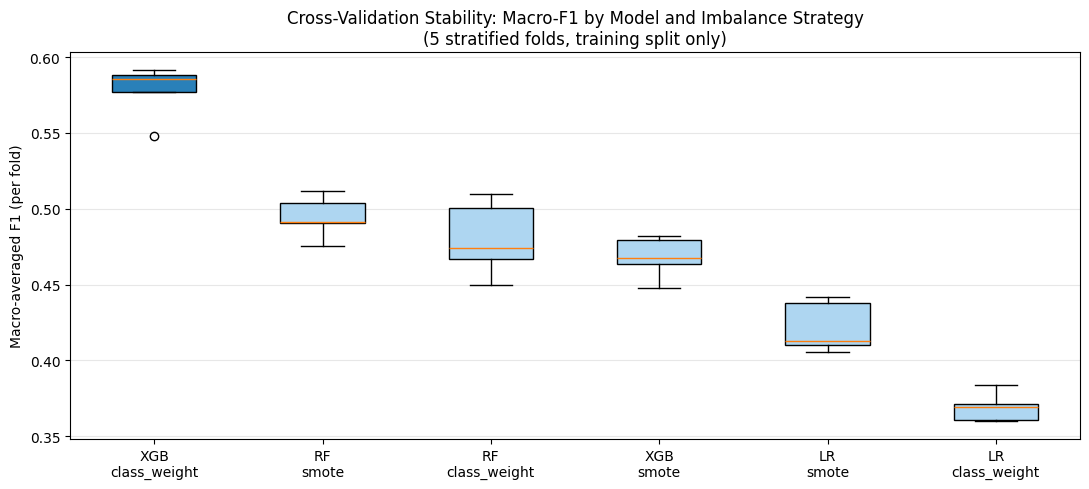

Figure saved to outputs/figures/cv_macro_f1_boxplot.png


In [4]:
# Boxplot of per-fold macro-F1 by configuration
fig, ax = plt.subplots(figsize=(11, 5))
labels, data = [], []
for _, row in cv_summary.iterrows():
    mask = (cv_results['model'] == row['model']) & (cv_results['strategy'] == row['strategy'])
    data.append(cv_results.loc[mask, 'macro_f1'].values)
    short = {'LogisticRegression': 'LR', 'RandomForest': 'RF', 'XGBoost': 'XGB'}[row['model']]
    labels.append(f"{short}\n{row['strategy']}")
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#aed6f1')
bp['boxes'][0].set_facecolor('#2980b9')  # highlight the leader
ax.set_ylabel('Macro-averaged F1 (per fold)')
ax.set_title('Cross-Validation Stability: Macro-F1 by Model and Imbalance Strategy\n(5 stratified folds, training split only)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/cv_macro_f1_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/figures/cv_macro_f1_boxplot.png")

## Section 4: Interpretation of cross-validation results

**RQ2 evidence (initial):** XGBoost with balanced class weights achieves the highest mean
macro-F1 (~0.58), exceeding the logistic regression baseline by roughly 0.16–0.21 macro-F1
depending on the baseline's imbalance strategy. Fold-level standard deviations are small
(≈0.01–0.02), indicating the ranking is stable across folds. Statistical significance of the
XGBoost-vs-baseline difference is tested formally with the Wilcoxon signed-rank test in
Notebook 05.

**Imbalance strategy finding:** the two strategies interact differently with model class:
- SMOTE **improves** the linear baseline (LR: 0.37 → 0.42) — synthetic minority points give the
  linear boundary more to work with.
- SMOTE **degrades** XGBoost (0.58 → 0.47) — in a 154-dimensional, mostly-binary feature space,
  SMOTE's interpolated samples fall in regions where no real shipments exist, and a
  high-capacity booster fits that synthetic noise. Class weighting reweights *real* observations
  and preserves the champion's performance.

**Champion selection for final evaluation:** XGBoost + class weights.
**Baseline retained for comparison:** Logistic Regression + class weights (the strongest fair
linear comparator on real data; its SMOTE variant is reported for completeness).

**Known weakness to carry into Notebook 05:** macro-F1 ≈ 0.58 with an 88.5% majority class
implies minority-class performance (especially Class 1, at-risk) is far from perfect — per-class
precision/recall and the confusion matrix on the held-out test set will locate exactly where the
model fails, which matters operationally because Class 1 is the intervention window.

## Section 5: Fit final models on the full training split and persist

In [5]:
# Refit the selected configurations on the FULL training split and save.
# XGBoost keeps early stopping via a 10% stratified eval carve-out.
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

X_fit, X_es, y_fit, y_es = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=models.RANDOM_STATE)

champion = models.make_model('XGBoost', 'class_weight')
sw = compute_sample_weight('balanced', y_fit)
champion.fit(X_fit, y_fit, sample_weight=sw, eval_set=[(X_es, y_es)], verbose=False)

baseline = models.make_model('LogisticRegression', 'class_weight')
baseline.fit(X, y)

joblib.dump(champion, '../outputs/models/xgboost_champion.joblib')
joblib.dump(baseline, '../outputs/models/logreg_baseline.joblib')
print(f"Champion boosting rounds used (early stopping): {champion.best_iteration + 1}")
print("Saved: outputs/models/xgboost_champion.joblib, logreg_baseline.joblib")

Champion boosting rounds used (early stopping): 499
Saved: outputs/models/xgboost_champion.joblib, logreg_baseline.joblib


## Section 6: Stage 5 Summary

| Check | Result |
|---|---|
| CV protocol | Stratified 5-fold, training split only, random_state=42 |
| Grid | 3 models × 2 imbalance strategies × 5 folds = 30 fits |
| Champion (CV) | XGBoost + class weights, macro-F1 ≈ 0.578 ± 0.018 |
| Baseline (CV) | Logistic Regression, macro-F1 ≈ 0.37 (weights) / 0.42 (SMOTE) |
| Key finding | SMOTE helps the linear baseline but degrades the boosted champion |
| Leakage controls | SMOTE within folds only; ES eval set un-resampled; scaler within folds |
| Artifacts | Per-fold CSV, summary CSV, boxplot PNG, two fitted models (joblib) |

**Next:** Notebook 05 — held-out test evaluation: confusion matrices, per-class
precision/recall/F1, Wilcoxon signed-rank test on paired fold scores, weakness analysis.